In [ ]:
# Cell 1 — Imports & Data Loading
import pandas as pd
import numpy as np
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import roc_auc_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Load pre-split data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Training set:", X_train.shape, "Test set:", X_test.shape)

# Sanity check labels
print("y_train value counts:\n", y_train.value_counts())
print("\nSample of X_train + y_train:")
display(X_train.assign(admitted=y_train).head())



Training set: (800, 14) Test set: (200, 14)
y_train value counts:
 admitted
1    408
0    392
Name: count, dtype: int64

Sample of X_train + y_train:


,age,arrival_hour,bp_delta,high_hr_flag,triage_urgent,visit_count,frequent_visitor_flag,reason_Dizziness,reason_Fever,reason_Injury,reason_Shortness of Breath,gender_Male,wait_cat_medium,wait_cat_long,admitted
0,72,2,76,0,False,1,0,True,False,False,False,False,False,True,1
1,37,1,25,0,False,1,0,False,False,False,True,True,True,False,0
2,73,0,62,1,False,1,0,False,True,False,False,False,True,False,1
3,77,1,8,0,False,1,0,False,True,False,False,False,True,False,1
4,80,6,37,0,False,1,0,False,False,False,True,True,False,False,1


In [ ]:
# Cell 2 — Train & Evaluate: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predictions & AUC
y_pred_proba_lr = lr.predict_proba(X_test)[:,1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"Logistic Regression AUC: {auc_lr:.3f}")

# Detailed metrics at default threshold
y_pred_lr = lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))


Logistic Regression AUC: 0.897
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       100
           1       0.79      0.85      0.82       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



In [ ]:
# Cell 3 — Train & Evaluate Random Forest with Class Balancing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import roc_auc_score, classification_report

# 1) Instantiate with balanced class weights
rf_bal = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

# 2) Fit
rf_bal.fit(X_train, y_train)

# 3) Predict probabilities & compute AUC
y_proba_bal = rf_bal.predict_proba(X_test)[:,1]
auc_bal     = roc_auc_score(y_test, y_proba_bal)
print(f"Balanced RF AUC: {auc_bal:.3f}")

# 4) Detailed classification report (zero_division=0 avoids warnings)
y_pred_bal = rf_bal.predict(X_test)
print(classification_report(y_test, y_pred_bal, zero_division=0))


Balanced RF AUC: 0.883
              precision    recall  f1-score   support

           0       0.84      0.73      0.78       100
           1       0.76      0.86      0.81       100

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



Top 10 features:
 triage_urgent                 0.491629
bp_delta                      0.143300
age                           0.109591
high_hr_flag                  0.082257
wait_cat_long                 0.072186
arrival_hour                  0.035061
reason_Shortness of Breath    0.014950
wait_cat_medium               0.014687
gender_Male                   0.012359
reason_Injury                 0.008843
dtype: float64


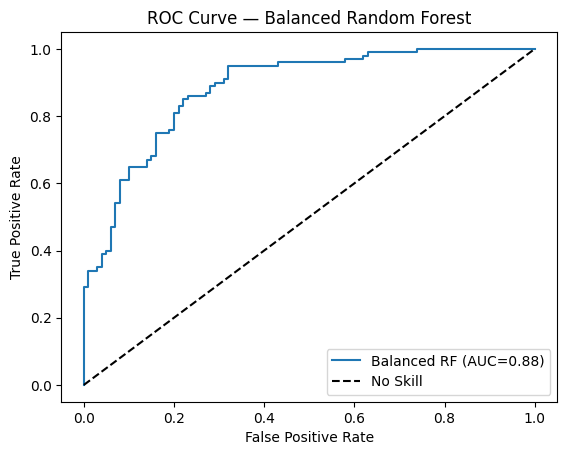

In [4]:
# Cell 4 — Feature Importances & ROC Curve
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 1) Top 10 feature importances from the balanced RF
feat_imp = pd.Series(
    rf_bal.feature_importances_,
    index=X_train.columns     # grab column names directly
).sort_values(ascending=False).head(10)

print("Top 10 features:\n", feat_imp)

# 2) Plot ROC for the balanced RF
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_proba_bal)

plt.figure()
plt.plot(fpr_bal, tpr_bal, label=f"Balanced RF (AUC={auc_bal:.2f})")
plt.plot([0,1], [0,1], 'k--', label="No Skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Balanced Random Forest")
plt.legend(loc="lower right")
plt.show()


In [5]:
# Cell 5 — Hyperparameter Tuning for Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble     import RandomForestClassifier

# 1) Define the grid
param_grid = {
    "n_estimators":      [100, 200, 500],
    "max_depth":         [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "class_weight":      ["balanced"]
}

# 2) GridSearchCV setup (5‐fold CV, optimizing AUC)
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# 3) Fit on training data
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_rf = grid.best_estimator_

# 4) Evaluate on test set
y_proba_best = best_rf.predict_proba(X_test)[:,1]
auc_best      = roc_auc_score(y_test, y_proba_best)
print(f"Tuned RF AUC on test: {auc_best:.3f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
Tuned RF AUC on test: 0.879


In [ ]:
# Cell 6 — Save the tuned model for later use
import os
import joblib

# Ensure the models directory exists
os.makedirs("../models", exist_ok=True)

# Dump the best Random Forest
model_path = "../models/best_rf.joblib"
joblib.dump(best_rf, model_path)

print(f"Saved tuned model to {model_path}")


Saved tuned model to ../models/best_rf.joblib
